# Linear regression

## Importación de librerías y paquetes y definición de constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
# To save models
import json
import pickle
# Modelado
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
# Métricas
from utils import get_classifier_metrics
# Warnings
import warnings

In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Vamos a probar tres enfoques diferentes para la generación de este modelo:

1. Dataset truncado
2. Dataset con valores nulos remplazados por la moda
3. Dataset con valores nulos remplazados por los k-nearest neighbors


## 1. Dataset truncado:

### Cargamos el dataset procedente del eda previo

In [3]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_filtrado.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,89,66,23,94,28.1,0.167,21,0
1,0,137,40,35,168,43.1,2.288,33,1
2,3,78,50,32,88,31.0,0.248,26,1
3,2,197,70,45,543,30.5,0.158,53,1
4,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
388,0,181,88,44,510,43.3,0.222,26,1
389,1,128,88,39,110,36.5,1.057,37,1
390,2,88,58,26,16,28.4,0.766,22,0
391,10,101,76,48,180,32.9,0.171,63,0


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [4]:
X = df.drop(["Outcome"], axis=1)
y = df['Outcome']
# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
327,1,100,74,12,46,19.5,0.149,28
125,3,191,68,15,130,30.9,0.299,34
363,2,127,46,21,335,34.4,0.176,22
292,2,95,54,14,88,26.1,0.748,22
126,5,96,74,18,67,33.6,0.997,43
...,...,...,...,...,...,...,...,...
129,2,100,70,52,57,40.5,0.677,25
145,0,126,84,29,215,30.7,0.520,24
343,9,145,80,46,130,37.9,0.637,40
192,0,93,100,39,72,43.4,1.021,35


### Modelado y Ajuste

In [30]:
dt_classifier_model = DecisionTreeClassifier(max_depth=5, random_state=24)
dt_classifier_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

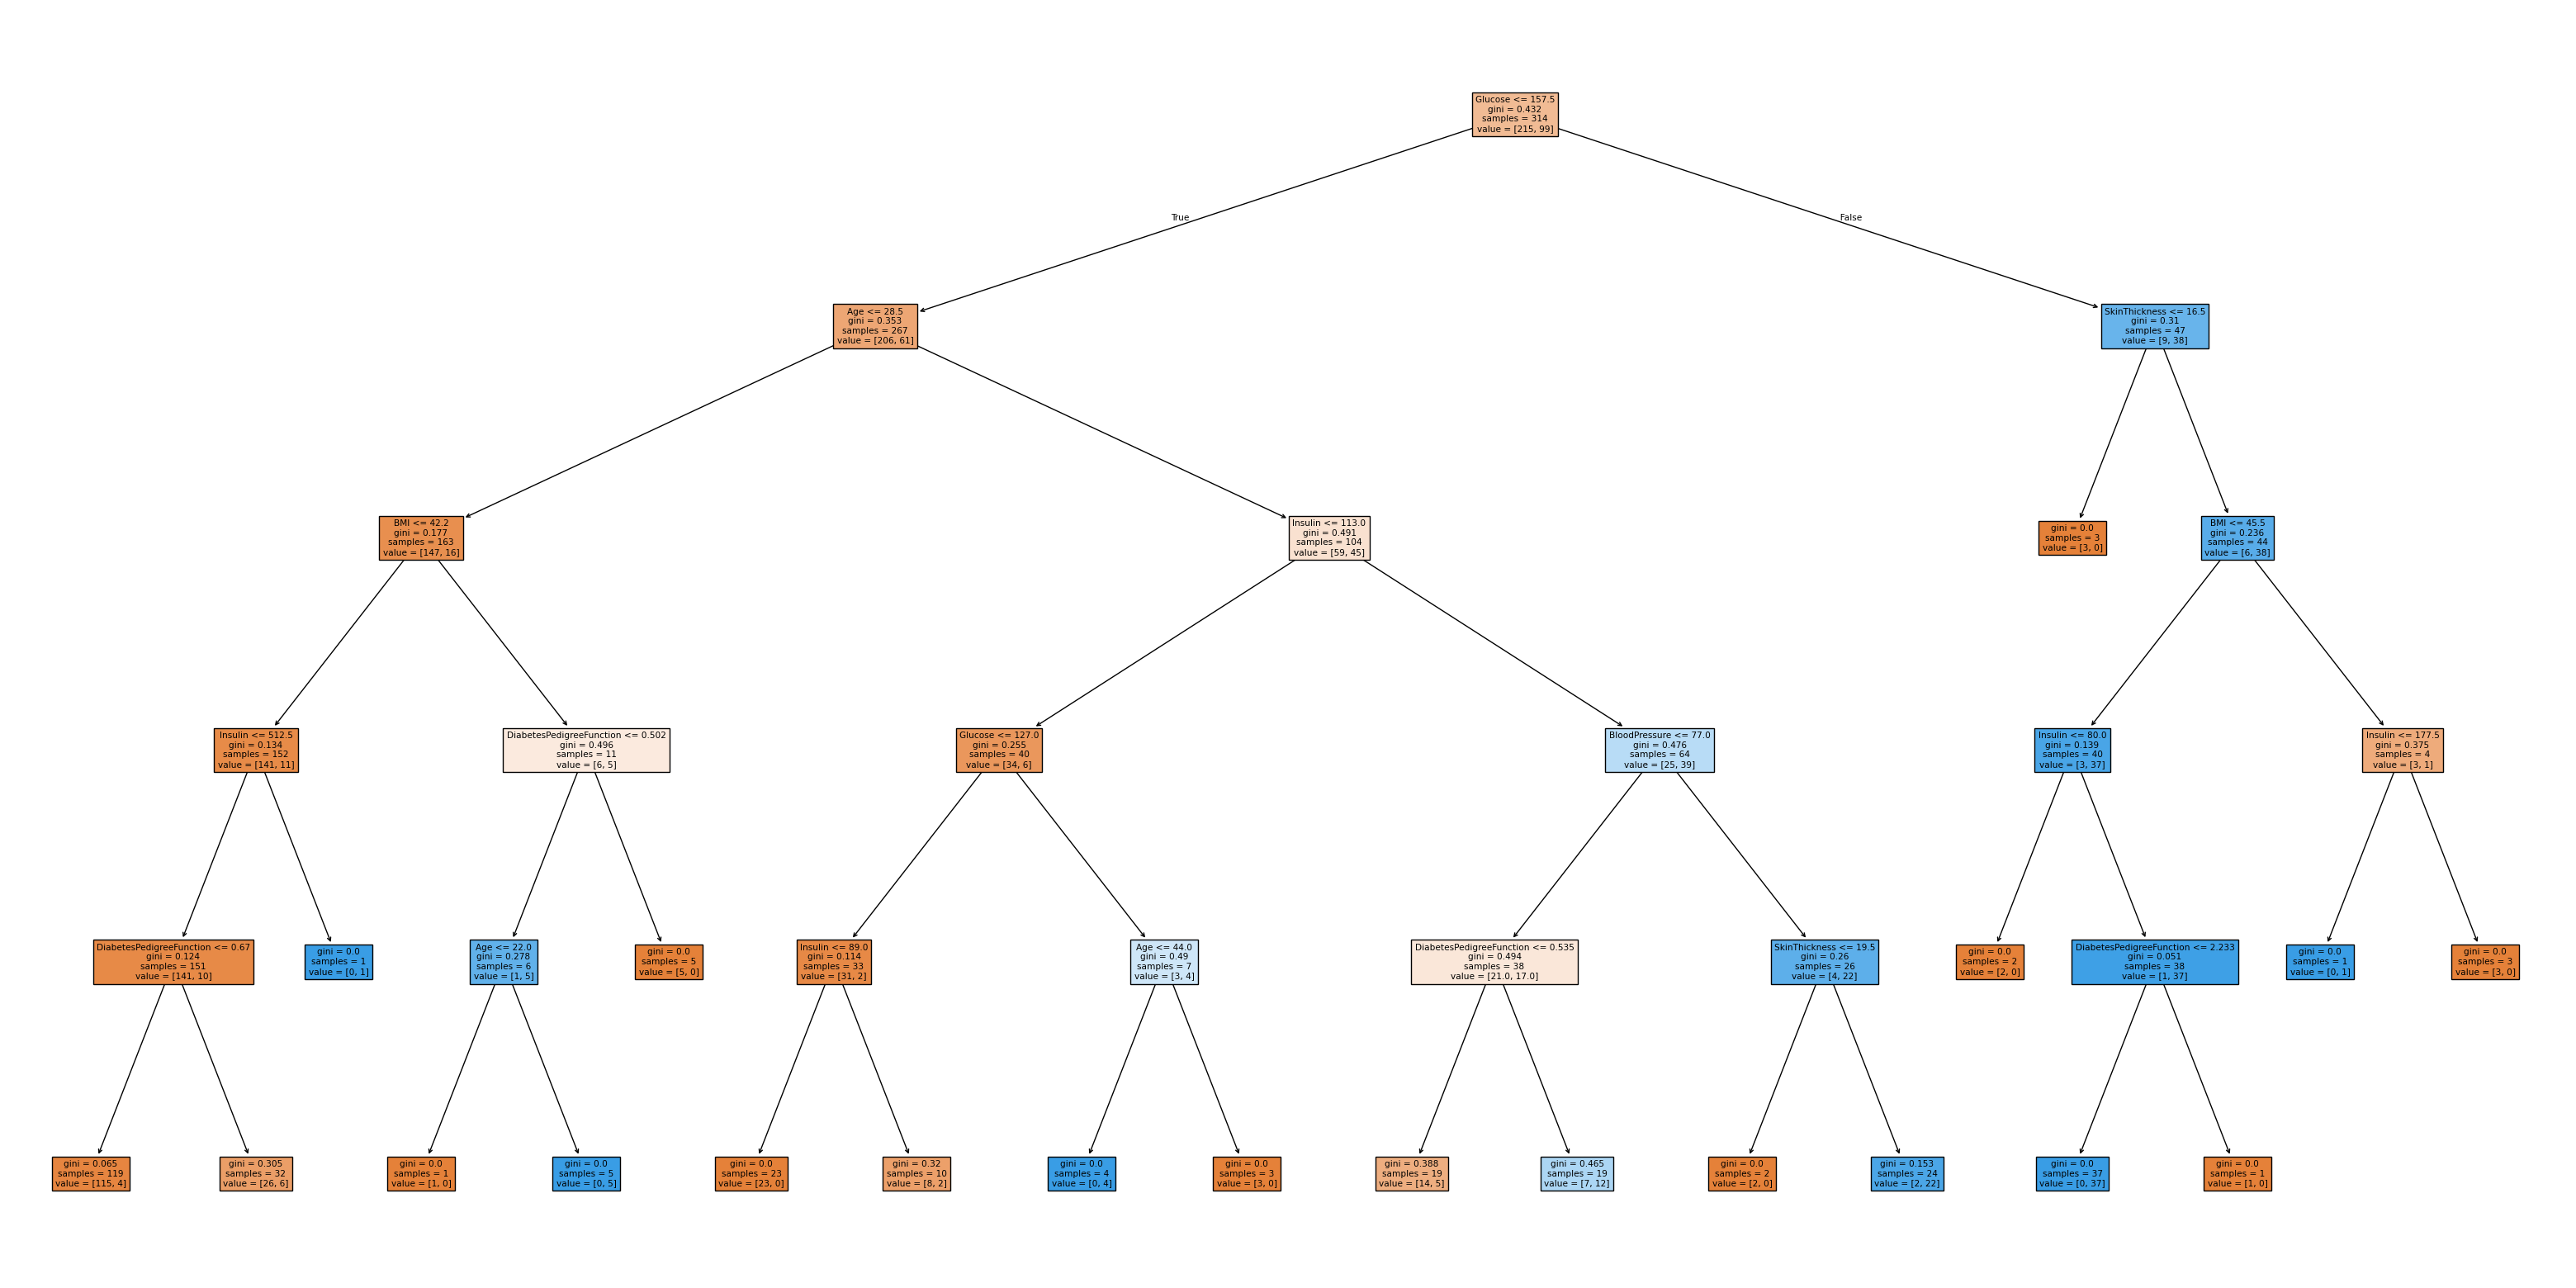

In [31]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train.columns),
               filled=True)
plt.show()

#### Si no ajustamos la profundidad del árbol pueden haber gráficos que no podamos manejar con facilidad, a priori lo dejamos así para comparar despues de optimizar parámetros

#### Predicción 

In [32]:
y_pred_test = dt_classifier_model.predict(X_test)
y_pred_test

array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1])

In [33]:
y_pred_train = dt_classifier_model.predict(X_train)
y_pred_train

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,

#### Métricas

In [ ]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.917197,0.917197,0.917197,0.917197
Test set,0.772152,0.772152,0.772152,0.772152


In [ ]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.917197,0.901899,0.912433,0.893211
Test set,0.772152,0.751050,0.768889,0.743952


In [ ]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.917197,0.916210,0.916620,0.917197
Test set,0.772152,0.766647,0.770802,0.772152


#### Oservamos que cuanto menos profundidad tiene el árbol, las métricas de y-test son mejores pero las de y-train van empeorando y que las métricas en micro son las que mejor resultado dan

### 2. Dataset con valores nulos remplazados por la moda

In [37]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_mode.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,105.0,33.6,0.627,50,1
1,1,85,66,29.0,105.0,26.6,0.351,31,0
2,8,183,64,32.0,105.0,23.3,0.672,32,1
3,1,89,66,23.0,94.0,28.1,0.167,21,0
4,0,137,40,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.0,180.0,32.9,0.171,63,0
764,2,122,70,27.0,105.0,36.8,0.340,27,0
765,5,121,72,23.0,112.0,26.2,0.245,30,0
766,1,126,60,32.0,105.0,30.1,0.349,47,1


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [38]:
X = df.drop(["Outcome"], axis=1)
y = df['Outcome']
# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
280,0,146,70,32.0,105.0,37.9,0.334,28
528,0,117,66,31.0,188.0,30.8,0.493,22
569,0,121,66,30.0,165.0,34.3,0.203,33
495,6,166,74,32.0,105.0,26.6,0.304,66
638,7,97,76,32.0,91.0,40.9,0.871,32
...,...,...,...,...,...,...,...,...
145,0,102,75,23.0,105.0,0.0,0.572,21
401,6,137,61,32.0,105.0,24.2,0.151,55
343,5,122,86,32.0,105.0,34.7,0.290,33
192,7,159,66,32.0,105.0,30.4,0.383,36


### Modelado y Ajuste

In [46]:
dt_classifier_model = DecisionTreeClassifier(max_depth=8, random_state=24)
dt_classifier_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

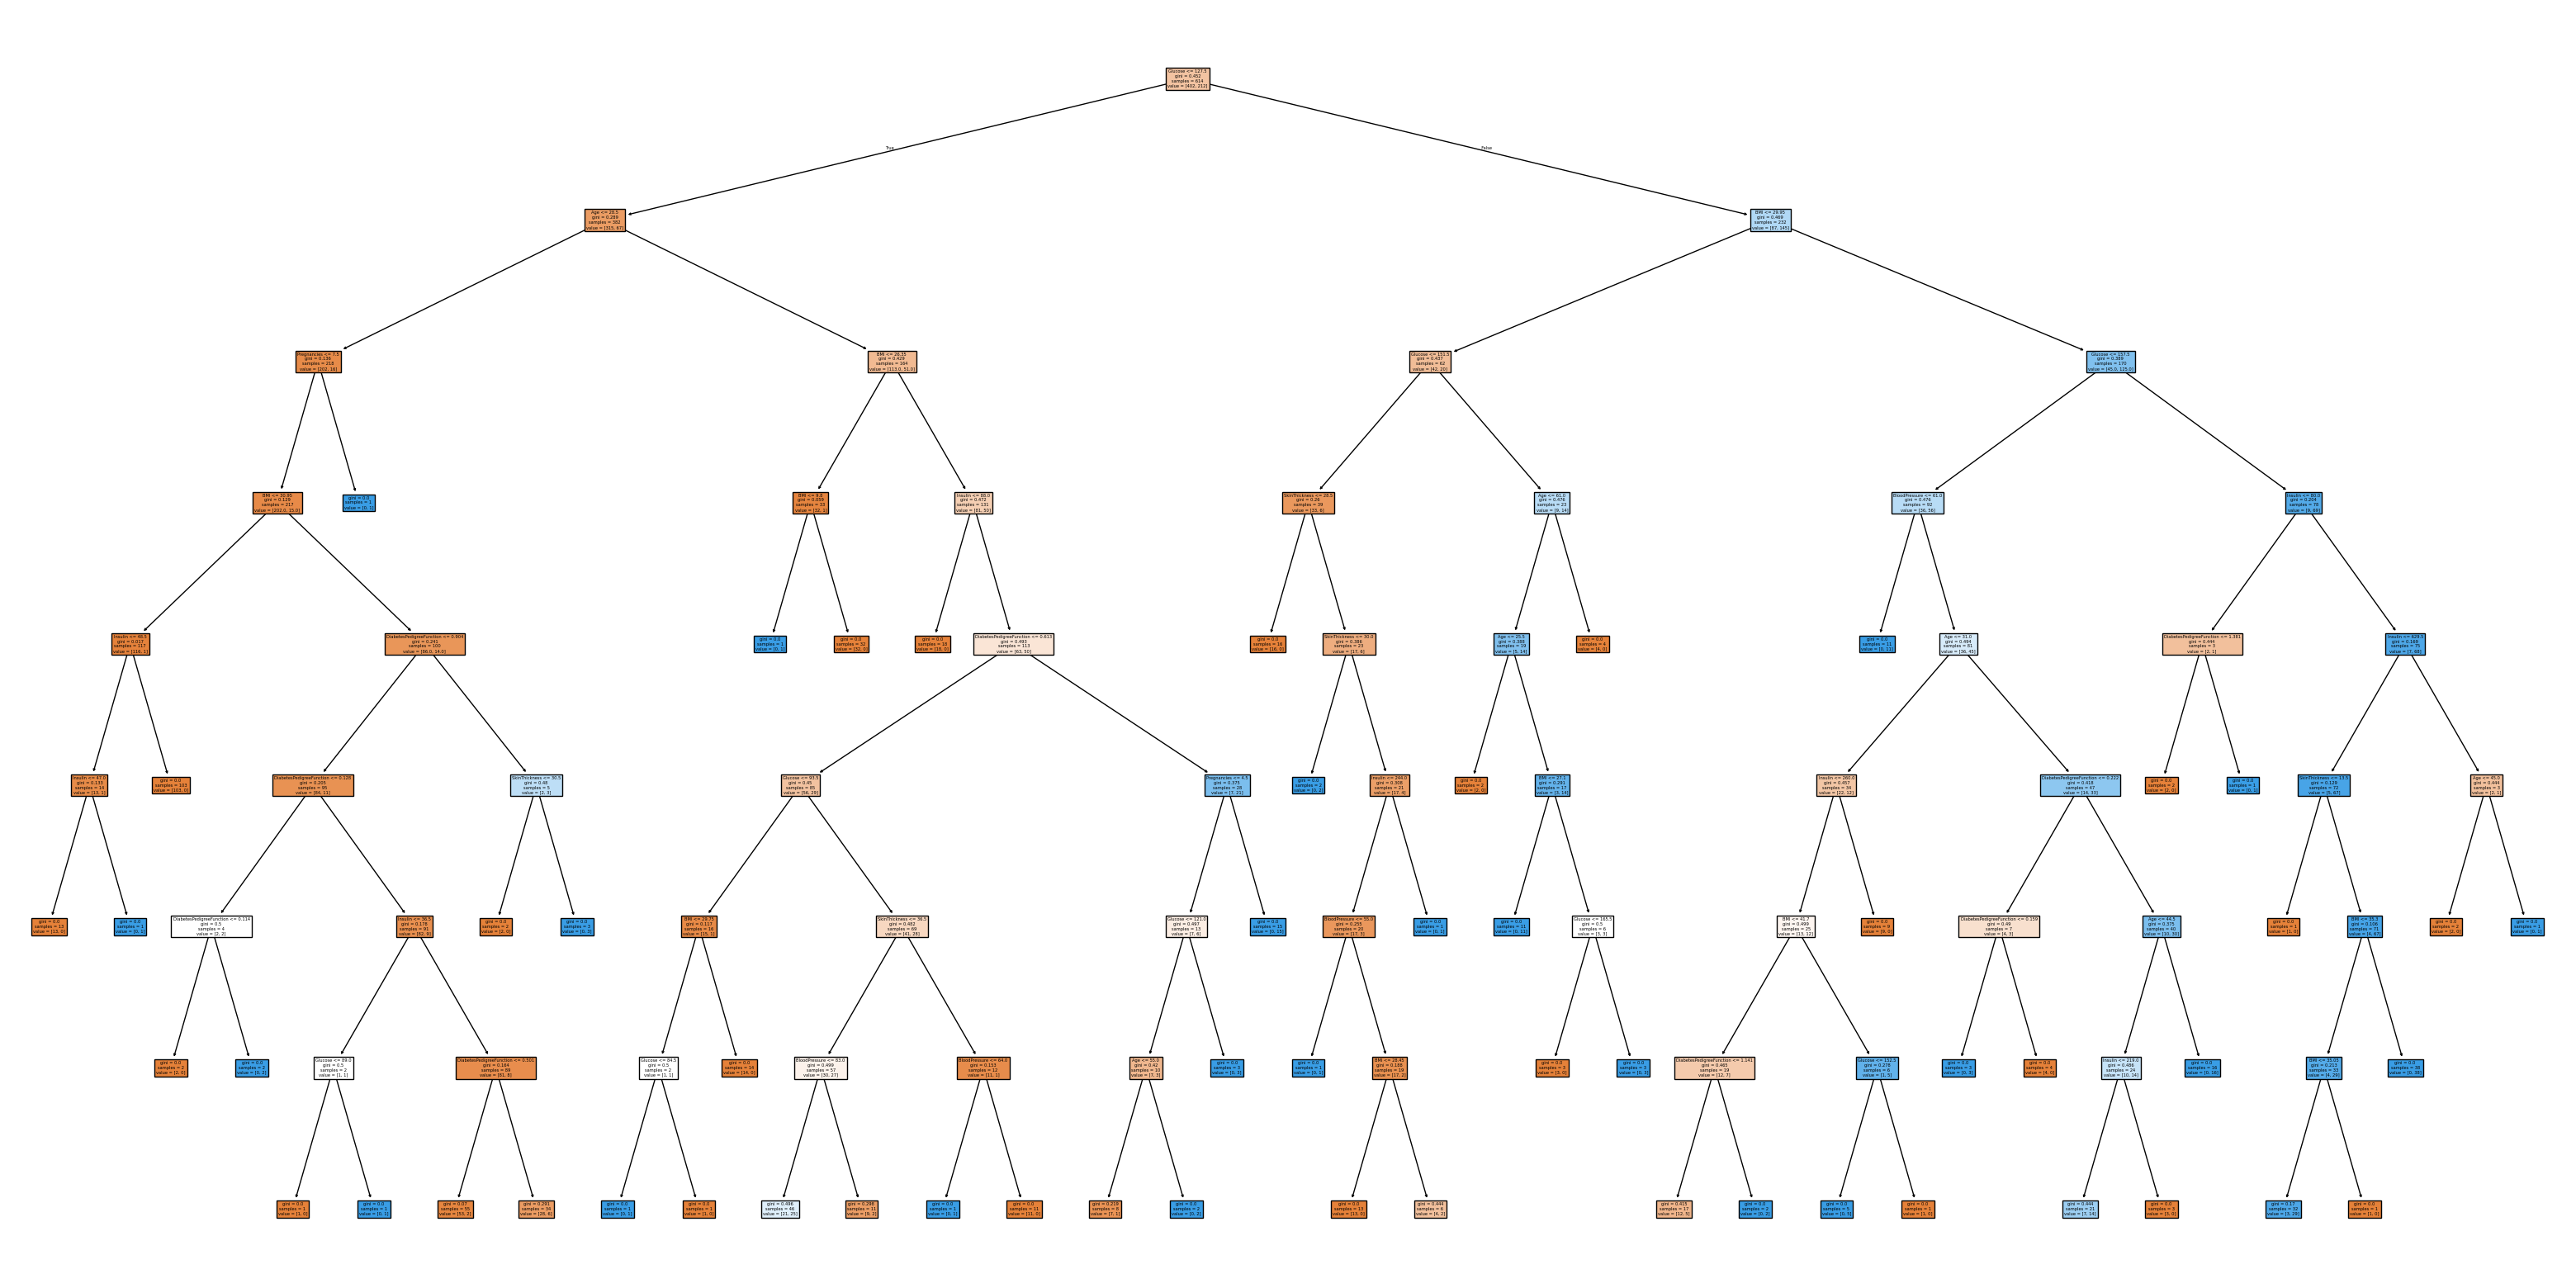

In [47]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train.columns),
               filled=True)
plt.show()

#### Observamos que al tener más cantidad de datos el algoritmo se vuelve más complejo

#### Predicción 

In [48]:
y_pred_test = dt_classifier_model.predict(X_test)
y_pred_test

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [49]:
y_pred_train = dt_classifier_model.predict(X_train)
y_pred_train

array([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,

#### Métricas

In [50]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.920195,0.920195,0.920195,0.920195
Test set,0.753247,0.753247,0.753247,0.753247


In [51]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.920195,0.912962,0.907975,0.918990
Test set,0.753247,0.737249,0.734574,0.741071


In [52]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.920195,0.920727,0.922133,0.920195
Test set,0.753247,0.754931,0.757640,0.753247


#### Observo que la tendencia general es que cuanto menos profundidad mejores métricas

### 2. Dataset con valores nulos remplazados por los k-nearest neighbors

In [53]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/df_diabetes_kn.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.00000,232.600000,33.6,0.627,50,1
1,1,85,66,29.00000,184.800000,26.6,0.351,31,0
2,8,183,64,29.15342,155.548223,23.3,0.672,32,1
3,1,89,66,23.00000,94.000000,28.1,0.167,21,0
4,0,137,40,35.00000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.00000,180.000000,32.9,0.171,63,0
764,2,122,70,27.00000,155.400000,36.8,0.340,27,0
765,5,121,72,23.00000,112.000000,26.2,0.245,30,0
766,1,126,60,29.15342,155.548223,30.1,0.349,47,1


### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable Outcome' como target

In [54]:
X = df.drop(["Outcome"], axis=1)
y = df['Outcome']
# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
280,0,146,70,29.15342,155.548223,37.9,0.334,28
528,0,117,66,31.00000,188.000000,30.8,0.493,22
569,0,121,66,30.00000,165.000000,34.3,0.203,33
495,6,166,74,29.15342,155.548223,26.6,0.304,66
638,7,97,76,32.00000,91.000000,40.9,0.871,32
...,...,...,...,...,...,...,...,...
145,0,102,75,23.00000,98.200000,0.0,0.572,21
401,6,137,61,29.15342,155.548223,24.2,0.151,55
343,5,122,86,29.15342,155.548223,34.7,0.290,33
192,7,159,66,29.15342,155.548223,30.4,0.383,36


### Modelado y Ajuste

In [63]:
dt_classifier_model = DecisionTreeClassifier(max_depth=8, random_state=24)
dt_classifier_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Visualización del arbol de decisión

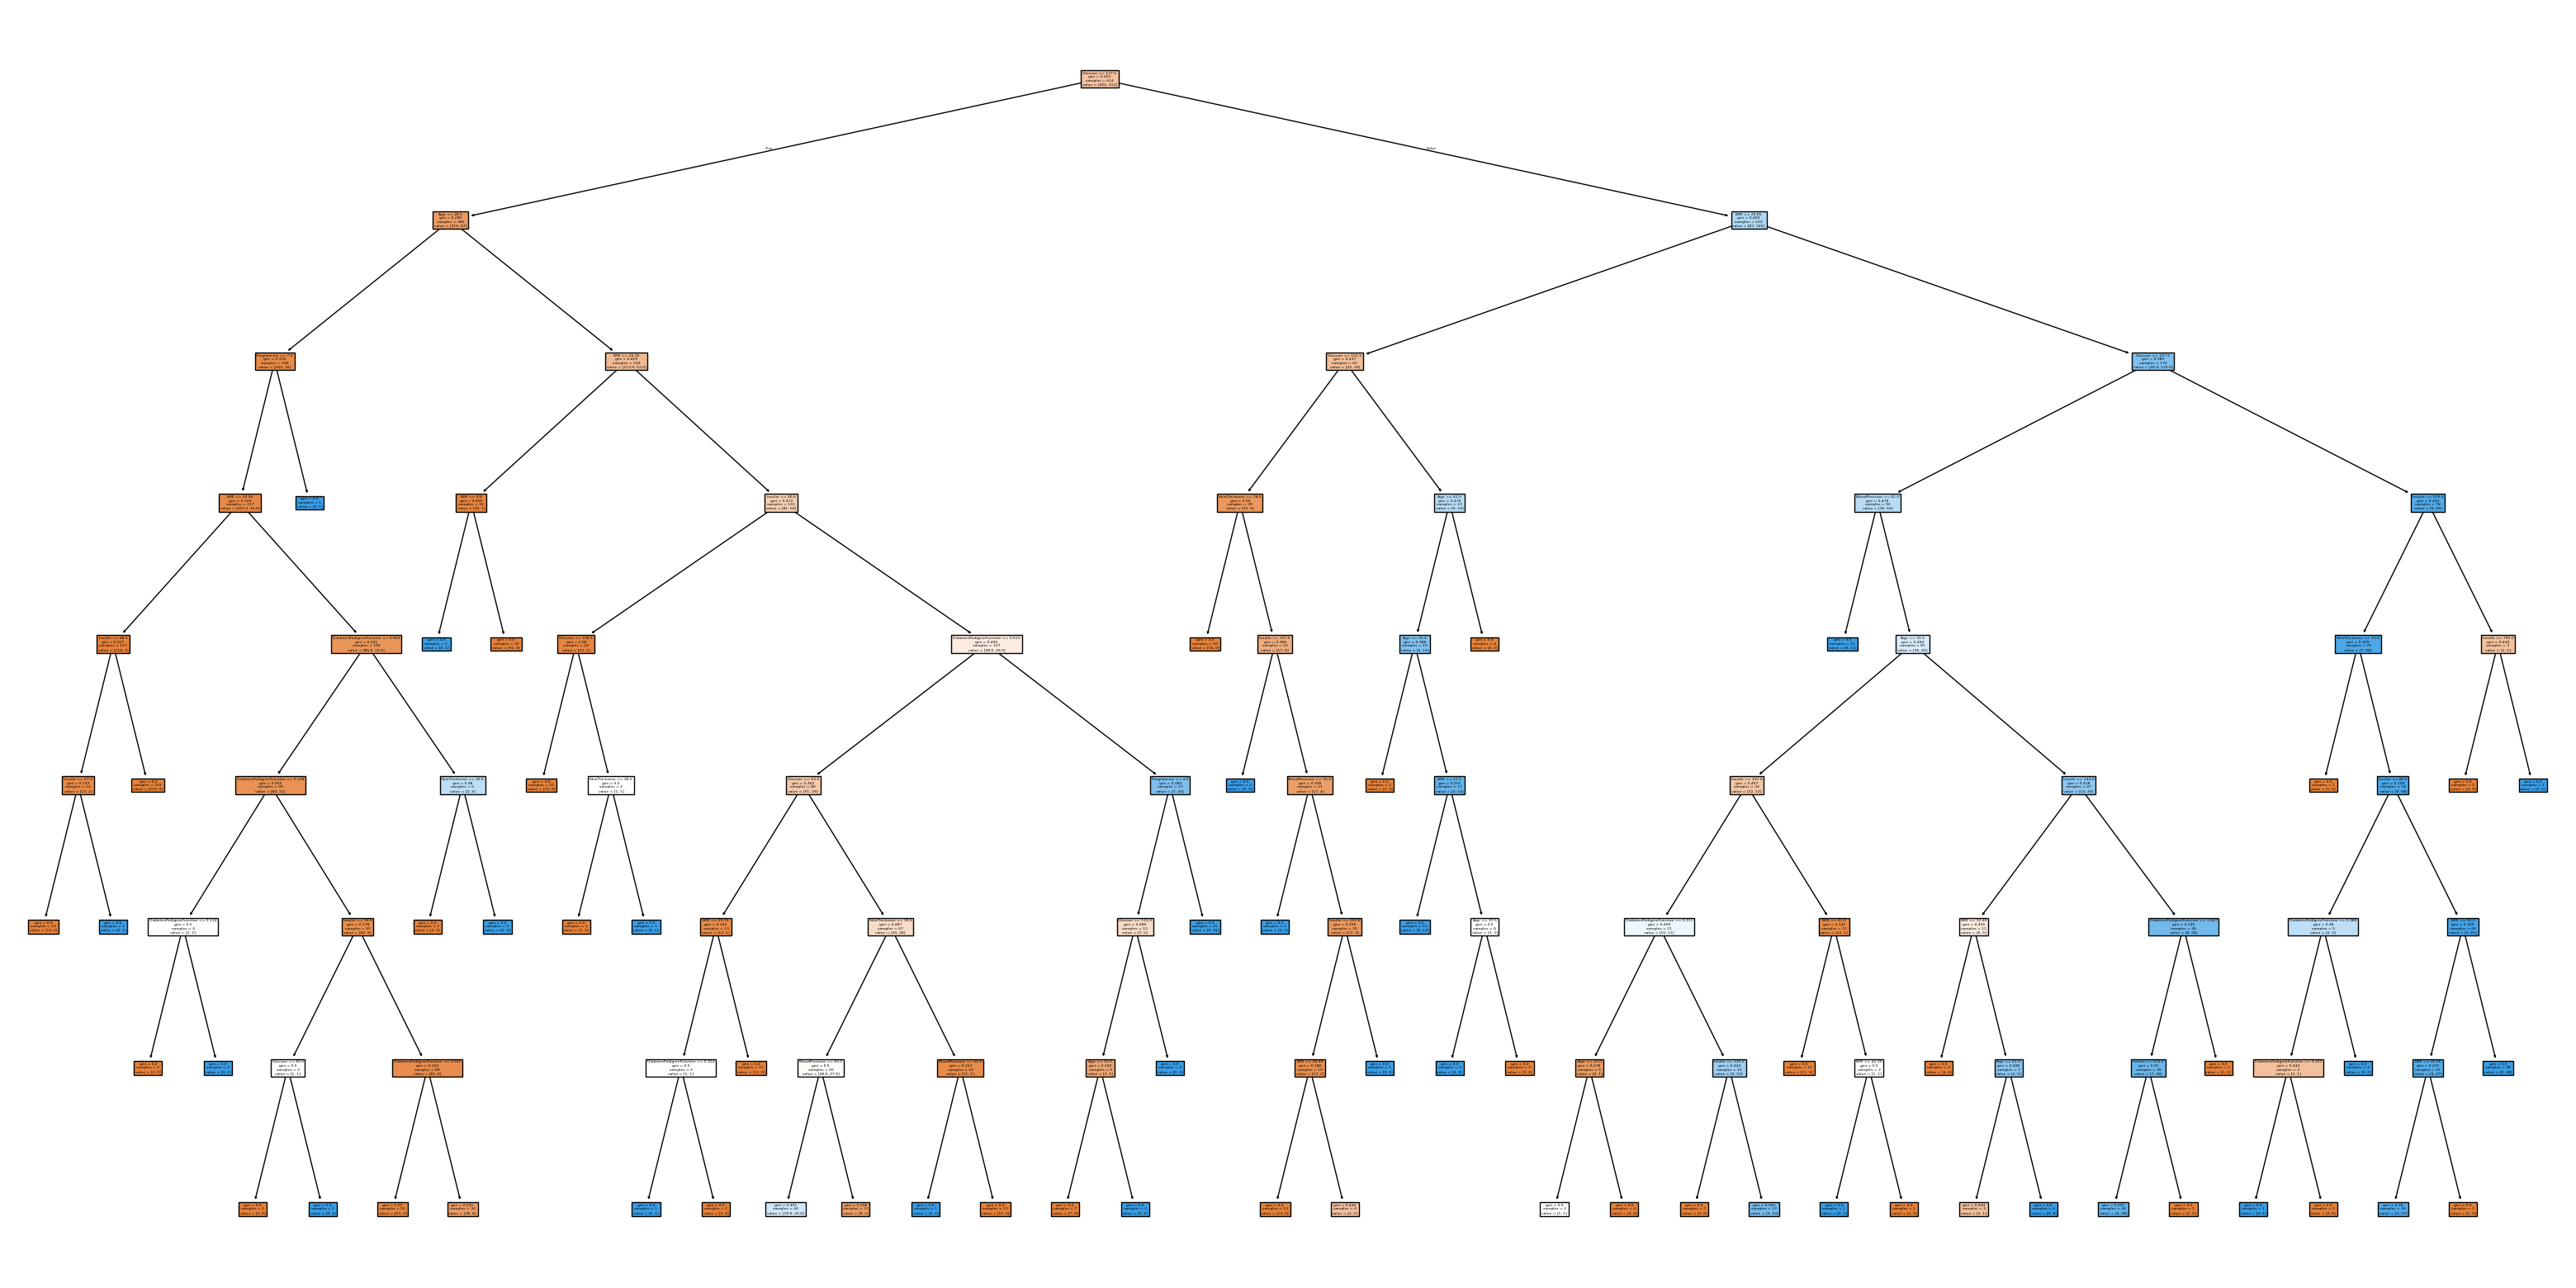

In [64]:
plt.figure(figsize=(40, 20))

tree.plot_tree(dt_classifier_model,
               feature_names=list(X_train.columns),
               filled=True)
plt.show()

#### Observamos una complejidad parecida al anterior modelo, hay que analizar las métricas para comparar

#### Predicción 

In [65]:
y_pred_test = dt_classifier_model.predict(X_test)
y_pred_test

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

In [66]:
y_pred_train = dt_classifier_model.predict(X_train)
y_pred_train

array([1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,

#### Métricas

In [67]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train) # Micro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.926710,0.926710,0.926710,0.926710
Test set,0.733766,0.733766,0.733766,0.733766


In [68]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, "macro") # Macro average

,Accuracy,F1 Score,Precision,Recall
Train set,0.926710,0.920390,0.914133,0.928424
Test set,0.733766,0.715522,0.713559,0.718112


In [69]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average="weighted") # Weighted average

,Accuracy,F1 Score,Precision,Recall
Train set,0.926710,0.927331,0.929451,0.926710
Test set,0.733766,0.735170,0.737134,0.733766
